# Employee Attendance & Productivity Tracker — Week 4
## ETL Pipeline in Azure Databricks
### Setup: Upload cleaned data to DBFS

In [0]:
attendance_data = """employee_id,employee_name,department,work_date,clock_in,clock_out,tasks_completed,tasks_assigned,status,work_hours,break_time_hrs,late_login,productivity_score
1,Rahul Sharma,Engineering,2026-06-01,2026-06-01 09:05:00,2026-06-01 18:10:00,5,6,Present,9.08,0.08,False,0.55
2,Priya Reddy,Engineering,2026-06-01,2026-06-01 08:55:00,2026-06-01 18:00:00,8,8,Present,9.08,0.08,False,0.88
3,Amit Kumar,Sales,2026-06-01,2026-06-01 09:30:00,2026-06-01 17:45:00,3,5,Present,8.25,0.0,False,0.36
4,Sneha Patel,HR,2026-06-01,2026-06-01 09:00:00,2026-06-01 18:00:00,4,4,Present,9.0,0.0,False,0.44
5,Farhan Ali,Sales,2026-06-01,,,0,3,Absent,,,,0
6,Neha Singh,Marketing,2026-06-01,2026-06-01 09:15:00,2026-06-01 17:30:00,6,7,Present,8.25,0.0,False,0.73
7,Arjun Verma,Engineering,2026-06-01,2026-06-01 09:50:00,2026-06-01 18:20:00,5,5,Present,8.5,0.0,True,0.59
8,Meera Nair,Marketing,2026-06-01,2026-06-01 09:00:00,2026-06-01 17:00:00,4,6,Present,8.0,0.0,False,0.5
1,Rahul Sharma,Engineering,2026-06-02,2026-06-02 09:00:00,2026-06-02 18:00:00,6,6,Present,9.0,0.0,False,0.67
2,Priya Reddy,Engineering,2026-06-02,2026-06-02 09:10:00,2026-06-02 18:05:00,7,8,Present,8.92,0.0,False,0.78
3,Amit Kumar,Sales,2026-06-02,,,0,4,Absent,,,,0
4,Sneha Patel,HR,2026-06-02,2026-06-02 08:50:00,2026-06-02 17:55:00,5,5,Present,9.08,0.08,False,0.55
5,Farhan Ali,Sales,2026-06-02,2026-06-02 10:00:00,2026-06-02 18:30:00,2,4,Present,8.5,0.0,True,0.24
6,Neha Singh,Marketing,2026-06-02,2026-06-02 09:05:00,2026-06-02 17:40:00,5,6,Present,8.58,0.0,False,0.58
7,Arjun Verma,Engineering,2026-06-02,2026-06-02 09:00:00,2026-06-02 18:00:00,6,6,Present,9.0,0.0,False,0.67
8,Meera Nair,Marketing,2026-06-02,2026-06-02 09:20:00,2026-06-02 17:50:00,3,5,Present,8.5,0.0,False,0.35
1,Rahul Sharma,Engineering,2026-06-03,2026-06-03 10:15:00,2026-06-03 18:00:00,4,6,Present,7.75,0.0,True,0.52
2,Priya Reddy,Engineering,2026-06-03,2026-06-03 08:50:00,2026-06-03 17:55:00,8,8,Present,9.08,0.08,False,0.88
3,Amit Kumar,Sales,2026-06-03,2026-06-03 09:45:00,2026-06-03 17:30:00,3,5,Present,7.75,0.0,True,0.39
4,Sneha Patel,HR,2026-06-03,2026-06-03 09:00:00,2026-06-03 17:00:00,3,4,Present,8.0,0.0,False,0.38
5,Farhan Ali,Sales,2026-06-03,,,0,3,Absent,,,,0
6,Neha Singh,Marketing,2026-06-03,2026-06-03 10:30:00,2026-06-03 18:00:00,4,7,Present,7.5,0.0,True,0.53
7,Arjun Verma,Engineering,2026-06-03,2026-06-03 09:00:00,2026-06-03 18:10:00,6,6,Present,9.17,0.17,False,0.65
8,Meera Nair,Marketing,2026-06-03,2026-06-03 09:10:00,2026-06-03 17:45:00,5,6,Present,8.58,0.0,False,0.58
1,Rahul Sharma,Engineering,2026-06-04,2026-06-04 09:00:00,2026-06-04 18:00:00,6,6,Present,9.0,0.0,False,0.67
2,Priya Reddy,Engineering,2026-06-04,2026-06-04 09:00:00,2026-06-04 18:00:00,8,8,Present,9.0,0.0,False,0.88
3,Amit Kumar,Sales,2026-06-04,2026-06-04 10:20:00,2026-06-04 17:30:00,2,5,Present,7.17,0.0,True,0.28
4,Sneha Patel,HR,2026-06-04,2026-06-04 08:55:00,2026-06-04 17:50:00,4,4,Present,8.92,0.0,False,0.45
5,Farhan Ali,Sales,2026-06-04,2026-06-04 09:30:00,2026-06-04 18:00:00,3,4,Present,8.5,0.0,False,0.35
6,Neha Singh,Marketing,2026-06-04,2026-06-04 09:00:00,2026-06-04 17:30:00,6,7,Present,8.5,0.0,False,0.71
7,Arjun Verma,Engineering,2026-06-04,,,0,5,Absent,,,,0
8,Meera Nair,Marketing,2026-06-04,2026-06-04 09:15:00,2026-06-04 17:40:00,4,6,Present,8.42,0.0,False,0.48
1,Rahul Sharma,Engineering,2026-06-05,2026-06-05 09:10:00,2026-06-05 18:05:00,5,6,Present,8.92,0.0,False,0.56
2,Priya Reddy,Engineering,2026-06-05,2026-06-05 08:45:00,2026-06-05 17:50:00,7,8,Present,9.08,0.08,False,0.77
3,Amit Kumar,Sales,2026-06-05,2026-06-05 10:00:00,2026-06-05 17:30:00,3,5,Present,7.5,0.0,True,0.4
4,Sneha Patel,HR,2026-06-05,2026-06-05 09:00:00,2026-06-05 18:00:00,4,4,Present,9.0,0.0,False,0.44
5,Farhan Ali,Sales,2026-06-05,,,0,3,Absent,,,,0
6,Neha Singh,Marketing,2026-06-05,2026-06-05 09:00:00,2026-06-05 17:30:00,5,7,Present,8.5,0.0,False,0.59
7,Arjun Verma,Engineering,2026-06-05,2026-06-05 09:05:00,2026-06-05 18:00:00,6,6,Present,8.92,0.0,False,0.67
8,Meera Nair,Marketing,2026-06-05,2026-06-05 09:00:00,2026-06-05 17:30:00,4,6,Present,8.5,0.0,False,0.47"""

dbutils.fs.put('/FileStore/attendance/attendance_cleaned.csv', attendance_data, overwrite=True)
print('Files uploaded to DBFS!')


Wrote 4089 bytes.
Files uploaded to DBFS!


## Part 1: Load Data into Databricks

In [0]:
df_attendance = spark.read.csv('/FileStore/attendance/attendance_cleaned.csv', header=True, inferSchema=True)
df_attendance.printSchema()
display(df_attendance)


root
 |-- employee_id: integer (nullable = true)
 |-- employee_name: string (nullable = true)
 |-- department: string (nullable = true)
 |-- work_date: date (nullable = true)
 |-- clock_in: timestamp (nullable = true)
 |-- clock_out: timestamp (nullable = true)
 |-- tasks_completed: integer (nullable = true)
 |-- tasks_assigned: integer (nullable = true)
 |-- status: string (nullable = true)
 |-- work_hours: double (nullable = true)
 |-- break_time_hrs: double (nullable = true)
 |-- late_login: boolean (nullable = true)
 |-- productivity_score: double (nullable = true)



employee_id,employee_name,department,work_date,clock_in,clock_out,tasks_completed,tasks_assigned,status,work_hours,break_time_hrs,late_login,productivity_score
1,Rahul Sharma,Engineering,2026-06-01,2026-06-01T09:05:00.000Z,2026-06-01T18:10:00.000Z,5,6,Present,9.08,0.08,false,0.55
2,Priya Reddy,Engineering,2026-06-01,2026-06-01T08:55:00.000Z,2026-06-01T18:00:00.000Z,8,8,Present,9.08,0.08,false,0.88
3,Amit Kumar,Sales,2026-06-01,2026-06-01T09:30:00.000Z,2026-06-01T17:45:00.000Z,3,5,Present,8.25,0.0,false,0.36
4,Sneha Patel,HR,2026-06-01,2026-06-01T09:00:00.000Z,2026-06-01T18:00:00.000Z,4,4,Present,9.0,0.0,false,0.44
5,Farhan Ali,Sales,2026-06-01,null,null,0,3,Absent,null,null,null,0.0
6,Neha Singh,Marketing,2026-06-01,2026-06-01T09:15:00.000Z,2026-06-01T17:30:00.000Z,6,7,Present,8.25,0.0,false,0.73
7,Arjun Verma,Engineering,2026-06-01,2026-06-01T09:50:00.000Z,2026-06-01T18:20:00.000Z,5,5,Present,8.5,0.0,true,0.59
8,Meera Nair,Marketing,2026-06-01,2026-06-01T09:00:00.000Z,2026-06-01T17:00:00.000Z,4,6,Present,8.0,0.0,false,0.5
1,Rahul Sharma,Engineering,2026-06-02,2026-06-02T09:00:00.000Z,2026-06-02T18:00:00.000Z,6,6,Present,9.0,0.0,false,0.67
2,Priya Reddy,Engineering,2026-06-02,2026-06-02T09:10:00.000Z,2026-06-02T18:05:00.000Z,7,8,Present,8.92,0.0,false,0.78


## Part 2: Save as Bronze Delta Table

In [0]:
spark.sql('DROP TABLE IF EXISTS bronze_attendance')
df_attendance.write.format('delta').mode('overwrite').saveAsTable('bronze_attendance')
print('Bronze table created!')


Bronze table created!


## Part 3: Clean and Transform — Silver Layer

In [0]:
from pyspark.sql.functions import col, when, round as spark_round, date_format, avg, sum as spark_sum, count

df_attendance = df_attendance.fillna({'work_hours': 0, 'productivity_score': 0, 'tasks_completed': 0})
print('Nulls handled')


Nulls handled


In [0]:
# Add work_date month column
df_silver = df_attendance.withColumn('work_month', date_format(col('work_date'), 'yyyy-MM'))

# Add performance_band
df_silver = df_silver.withColumn('performance_band',
    when(col('productivity_score') >= 0.7, 'High')
    .when(col('productivity_score') >= 0.4, 'Medium')
    .otherwise('Low')
)

# Add attendance_flag
df_silver = df_silver.withColumn('attendance_flag',
    when(col('status') == 'Absent', 'Absent')
    .when(col('late_login') == True, 'Late')
    .otherwise('On Time')
)

display(df_silver.select('employee_id', 'employee_name', 'department', 'work_date', 'work_hours', 'productivity_score', 'performance_band', 'attendance_flag'))


employee_id,employee_name,department,work_date,work_hours,productivity_score,performance_band,attendance_flag
1,Rahul Sharma,Engineering,2026-06-01,9.08,0.55,Medium,On Time
2,Priya Reddy,Engineering,2026-06-01,9.08,0.88,High,On Time
3,Amit Kumar,Sales,2026-06-01,8.25,0.36,Low,On Time
4,Sneha Patel,HR,2026-06-01,9.0,0.44,Medium,On Time
5,Farhan Ali,Sales,2026-06-01,0.0,0.0,Low,Absent
6,Neha Singh,Marketing,2026-06-01,8.25,0.73,High,On Time
7,Arjun Verma,Engineering,2026-06-01,8.5,0.59,Medium,Late
8,Meera Nair,Marketing,2026-06-01,8.0,0.5,Medium,On Time
1,Rahul Sharma,Engineering,2026-06-02,9.0,0.67,Medium,On Time
2,Priya Reddy,Engineering,2026-06-02,8.92,0.78,High,On Time


In [0]:
# Save Silver Delta table
spark.sql('DROP TABLE IF EXISTS silver_attendance')
df_silver.write.format('delta').mode('overwrite').saveAsTable('silver_attendance')
print('Silver table saved!')


Silver table saved!


## Part 4: Gold Reports — Department-Level KPIs

In [0]:
df_silver.createOrReplaceTempView('silver_view')

# Department-level KPIs
print('--- Department KPIs ---')
spark.sql("""
    SELECT department,
           ROUND(AVG(work_hours), 2) AS avg_work_hours,
           ROUND(AVG(productivity_score), 2) AS avg_productivity,
           SUM(CASE WHEN status = 'Absent' THEN 1 ELSE 0 END) AS total_absences,
           SUM(CASE WHEN late_login = true THEN 1 ELSE 0 END) AS total_late_logins
    FROM silver_view
    GROUP BY department
    ORDER BY avg_productivity DESC
""").show()


--- Department KPIs ---
+-----------+--------------+----------------+--------------+-----------------+
| department|avg_work_hours|avg_productivity|total_absences|total_late_logins|
+-----------+--------------+----------------+--------------+-----------------+
|Engineering|           8.3|            0.65|             1|                2|
|  Marketing|          8.33|            0.55|             0|                1|
|         HR|           8.8|            0.45|             0|                0|
|      Sales|          4.77|             0.2|             4|                4|
+-----------+--------------+----------------+--------------+-----------------+



In [0]:
# Employee performance summary
print('--- Employee Performance Summary ---')
spark.sql("""
    SELECT employee_id, employee_name, department,
           ROUND(AVG(work_hours), 2) AS avg_work_hours,
           ROUND(AVG(productivity_score), 2) AS avg_productivity,
           SUM(CASE WHEN status = 'Absent' THEN 1 ELSE 0 END) AS total_absences,
           SUM(CASE WHEN late_login = true THEN 1 ELSE 0 END) AS late_logins
    FROM silver_view
    GROUP BY employee_id, employee_name, department
    ORDER BY avg_productivity DESC
""").show()


--- Employee Performance Summary ---
+-----------+-------------+-----------+--------------+----------------+--------------+-----------+
|employee_id|employee_name| department|avg_work_hours|avg_productivity|total_absences|late_logins|
+-----------+-------------+-----------+--------------+----------------+--------------+-----------+
|          2|  Priya Reddy|Engineering|          9.03|            0.84|             0|          0|
|          6|   Neha Singh|  Marketing|          8.27|            0.63|             0|          1|
|          1| Rahul Sharma|Engineering|          8.75|            0.59|             0|          1|
|          7|  Arjun Verma|Engineering|          7.12|            0.52|             1|          1|
|          8|   Meera Nair|  Marketing|           8.4|            0.48|             0|          0|
|          4|  Sneha Patel|         HR|           8.8|            0.45|             0|          0|
|          3|   Amit Kumar|      Sales|          6.13|            0.29| 

In [0]:
# Top performers
print('--- Top 3 Performers ---')
spark.sql("""
    SELECT employee_name, department,
           ROUND(AVG(productivity_score), 2) AS avg_productivity
    FROM silver_view
    GROUP BY employee_name, department
    ORDER BY avg_productivity DESC
    LIMIT 3
""").show()


--- Top 3 Performers ---
+-------------+-----------+----------------+
|employee_name| department|avg_productivity|
+-------------+-----------+----------------+
|  Priya Reddy|Engineering|            0.84|
|   Neha Singh|  Marketing|            0.63|
| Rahul Sharma|Engineering|            0.59|
+-------------+-----------+----------------+



In [0]:
# Flagged employees (2+ absences or 2+ late logins)
print('--- Flagged Employees (HR Review) ---')
spark.sql("""
    SELECT employee_name, department,
           SUM(CASE WHEN status = 'Absent' THEN 1 ELSE 0 END) AS total_absences,
           SUM(CASE WHEN late_login = true THEN 1 ELSE 0 END) AS late_logins
    FROM silver_view
    GROUP BY employee_name, department
    HAVING total_absences >= 2 OR late_logins >= 2
    ORDER BY total_absences DESC
""").show()


--- Flagged Employees (HR Review) ---
+-------------+----------+--------------+-----------+
|employee_name|department|total_absences|late_logins|
+-------------+----------+--------------+-----------+
|   Farhan Ali|     Sales|             3|          1|
|   Amit Kumar|     Sales|             1|          3|
+-------------+----------+--------------+-----------+



## Part 5: Save Gold Reports

In [0]:
gold_dept = spark.sql("""
    SELECT department,
           ROUND(AVG(work_hours), 2) AS avg_work_hours,
           ROUND(AVG(productivity_score), 2) AS avg_productivity,
           SUM(CASE WHEN status = 'Absent' THEN 1 ELSE 0 END) AS total_absences,
           SUM(CASE WHEN late_login = true THEN 1 ELSE 0 END) AS total_late_logins
    FROM silver_view GROUP BY department ORDER BY avg_productivity DESC
""")

gold_emp = spark.sql("""
    SELECT employee_id, employee_name, department,
           ROUND(AVG(work_hours), 2) AS avg_work_hours,
           ROUND(AVG(productivity_score), 2) AS avg_productivity,
           SUM(CASE WHEN status = 'Absent' THEN 1 ELSE 0 END) AS total_absences
    FROM silver_view GROUP BY employee_id, employee_name, department
    ORDER BY avg_productivity DESC
""")

spark.sql('DROP TABLE IF EXISTS gold_dept_kpis')
spark.sql('DROP TABLE IF EXISTS gold_employee_performance')

gold_dept.write.format('delta').mode('overwrite').saveAsTable('gold_dept_kpis')
gold_emp.write.format('delta').mode('overwrite').saveAsTable('gold_employee_performance')

gold_dept.toPandas().to_csv('/tmp/gold_dept_kpis.csv', index=False)
gold_emp.toPandas().to_csv('/tmp/gold_employee_performance.csv', index=False)

print('Gold Delta tables and CSV files saved!')


Gold Delta tables and CSV files saved!


## Part 6: Visualizations

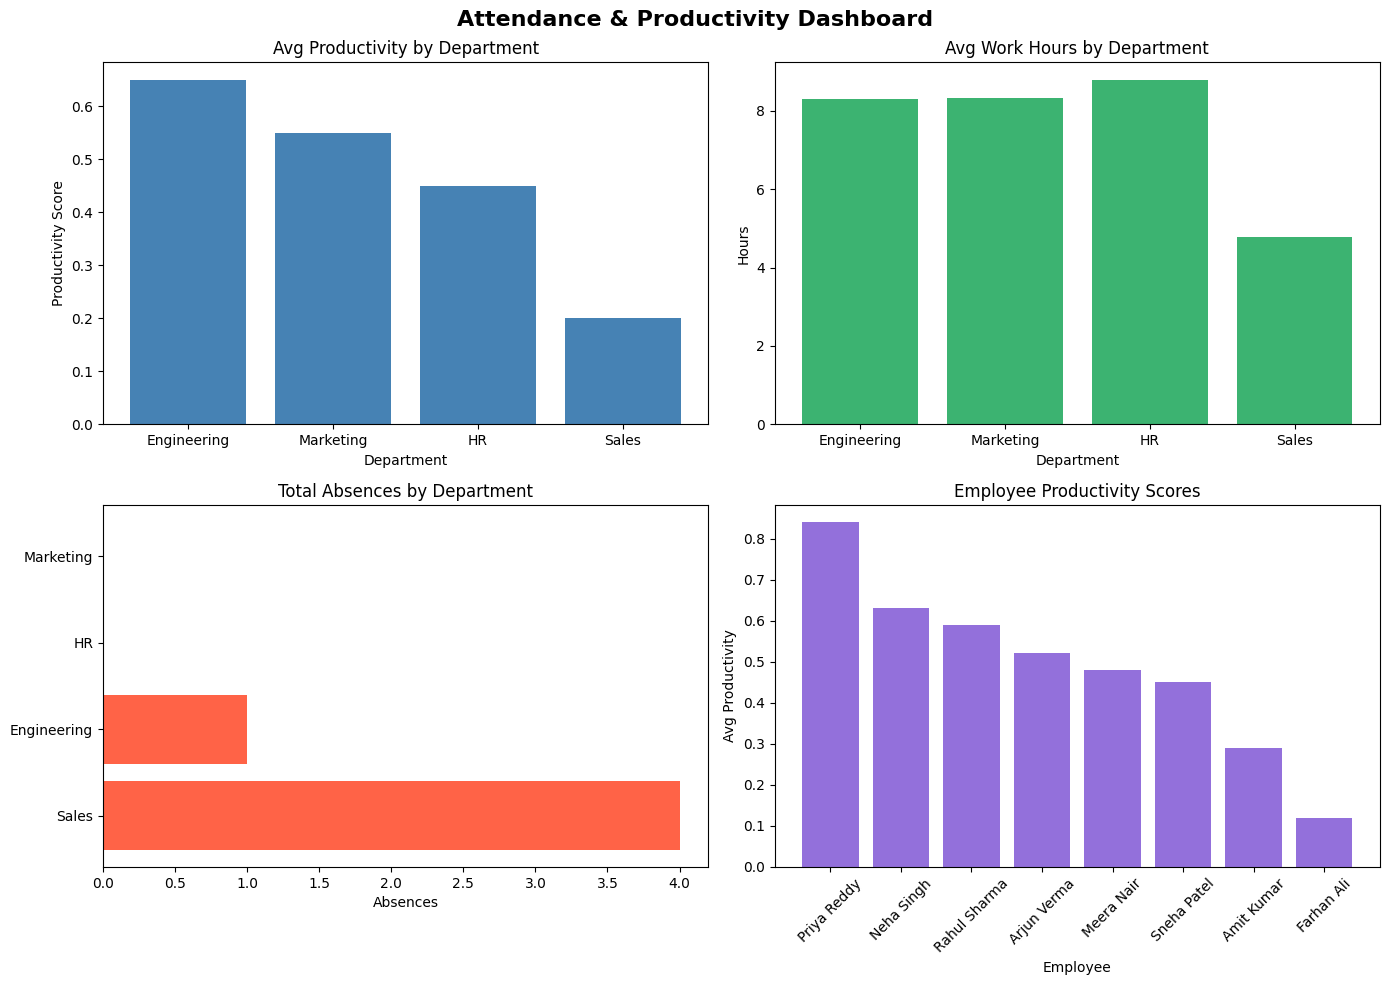

In [0]:
import matplotlib.pyplot as plt

dept_pd = gold_dept.toPandas()
emp_pd = gold_emp.toPandas()
absent_pd = spark.sql("""
    SELECT department, SUM(CASE WHEN status='Absent' THEN 1 ELSE 0 END) AS absences
    FROM silver_view GROUP BY department
""").toPandas()
trend_pd = spark.sql("""
    SELECT work_month, ROUND(AVG(productivity_score),2) AS avg_productivity
    FROM silver_view GROUP BY work_month ORDER BY work_month
""").toPandas()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].bar(dept_pd['department'], dept_pd['avg_productivity'], color='steelblue')
axes[0,0].set_title('Avg Productivity by Department')
axes[0,0].set_xlabel('Department')
axes[0,0].set_ylabel('Productivity Score')

axes[0,1].bar(dept_pd['department'], dept_pd['avg_work_hours'], color='mediumseagreen')
axes[0,1].set_title('Avg Work Hours by Department')
axes[0,1].set_xlabel('Department')
axes[0,1].set_ylabel('Hours')

axes[1,0].barh(absent_pd['department'], absent_pd['absences'], color='tomato')
axes[1,0].set_title('Total Absences by Department')
axes[1,0].set_xlabel('Absences')

axes[1,1].bar(emp_pd['employee_name'], emp_pd['avg_productivity'], color='mediumpurple')
axes[1,1].set_title('Employee Productivity Scores')
axes[1,1].set_xlabel('Employee')
axes[1,1].set_ylabel('Avg Productivity')
axes[1,1].tick_params(axis='x', rotation=45)

plt.suptitle('Attendance & Productivity Dashboard', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
